In [1]:
import tensorflow as tf
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

import sys
sys.path.append('./rtaUtils')

import wandb, os
from wandb.keras import WandbCallback
os.environ["WANDB_SILENT"] = "true"

from rtaUtils import paths, experiment, data_loading, data_preparation

# Disable GPU
tf.config.set_visible_devices([], 'GPU')
visible_devices = tf.config.get_visible_devices()
print(visible_devices)
for device in visible_devices:
    assert device.device_type != 'GPU'

2023-07-09 21:53:53.426352: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-07-09 21:53:53.434511: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-07-09 21:53:53.434538: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


2023-07-09 21:53:56.101806: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2023-07-09 21:53:56.101862: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2023-07-09 21:53:56.101898: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (tfg-6538): /proc/driver/nvidia/version does not exist


In [2]:
### Experiment setup ##########################################################
model_type   = '10LSTMtrayDensasTrackSectorAllFeatures'

# Features
numeric_feat   = ["latitude", "longitude", "altitude",'track','sector','hav_distance','speed']
categoric_feat = ["aerodromeOfDeparture"]  
objective      = ['latitude', 'longitude', 'altitude']

# Data parameters
months       = '*' # 20220[123456789]
airport      = '*'
sampling     = 15
from_parquet = True # Load from parquet files

# Model configuration
lookback     = 55
lookforward  = 10
shift        = 0

n_units      = 30
act_function = 'sigmoid'
batch_size   = 128

epochs       = 40

In [3]:
# Auxiliar parameters
glob_text    = f'{months}-{airport}'
model_config = dict(
    n_units=n_units,
    act_function=act_function,
    batch_size=batch_size,
)

feat_dict = dict(
    numeric=numeric_feat,
    categoric=categoric_feat,
    objective=objective
)

In [15]:
#Añadir api KEY
!wandb login 
# Configuración para Weights and Biases
dt = datetime.datetime.now().strftime('%m%d_%H%M')

wandb_config = {
    'batch_size' : batch_size,
    'lookback' : lookback,
    'n_units' : n_units,
    'sampling' : sampling,
    'model_type' : model_type
}
wandb.init(project='VM_RTAs', config=wandb_config,
           name=f'{model_type}_s{sampling}_lb{lookback}_u{n_units}_{dt}'           
          ) 
wandCallback = WandbCallback(save_model=False)

## Training process

In [6]:
# Instanciación de Experiment
experimento = experiment.ExperimentTrajectory(
    model_type = model_type,
    lookback=lookback,
    sampling=sampling,
    model_config=model_config,
    months=months, 
    airport=airport,
    features=feat_dict,
    lookforward=lookforward,
    shift=shift,
)
#experimento.init_model()
# Si ya se ha entrenado antes, load_model() carga el último modelo
experimento.load_model()
experimento.model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 30)                4680      
                                                                 
 dense (Dense)               (None, 30)                930       
                                                                 
 dense_1 (Dense)             (None, 30)                930       
                                                                 
 dense_2 (Dense)             (None, 30)                930       
                                                                 
 reshape (Reshape)           (None, 10, 3)             0         
                                                                 
Total params: 7,470
Trainable params: 7,470
Non-trainable params: 0
_________________________________________________________________


In [17]:
# Entrenamiento
history = experimento.train(epochs=epochs, from_parquet=from_parquet, add_callbacks=[wandCallback]) 

Epoch 1/40
14159/14159 [==============================] - 583s 41ms/step - loss: 0.0120 - mean_squared_error: 0.0023 - val_loss: 0.0050 - val_mean_squared_error: 1.9902e-04
Epoch 2/40
14159/14159 [==============================] - 564s 40ms/step - loss: 0.0047 - mean_squared_error: 1.9766e-04 - val_loss: 0.0044 - val_mean_squared_error: 1.7521e-04
Epoch 3/40
14159/14159 [==============================] - 573s 40ms/step - loss: 0.0044 - mean_squared_error: 1.8135e-04 - val_loss: 0.0046 - val_mean_squared_error: 1.6765e-04
Epoch 4/40
14159/14159 [==============================] - 567s 40ms/step - loss: 0.0042 - mean_squared_error: 1.7169e-04 - val_loss: 0.0046 - val_mean_squared_error: 1.6514e-04
Epoch 5/40
14159/14159 [==============================] - 566s 40ms/step - loss: 0.0040 - mean_squared_error: 1.6472e-04 - val_loss: 0.0042 - val_mean_squared_error: 1.5516e-04
Epoch 6/40
14159/14159 [==============================] - 569s 40ms/step - loss: 0.0039 - mean_squared_error: 1.5918e-0

KeyboardInterrupt: 

In [7]:
wandb.finish()

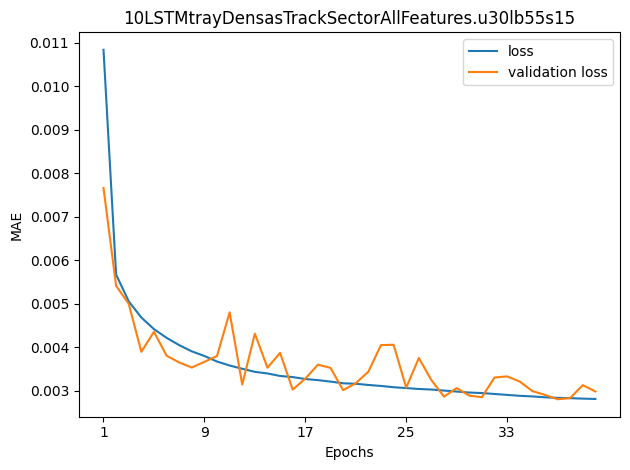

In [7]:
progress = pd.read_csv(experimento.model_path_log)
skip = 0

plt.plot([str(x) for x in range(1+skip,progress.shape[0]+1)], progress['loss'].iloc[skip:], label='loss')
plt.plot([str(x) for x in range(1+skip,progress.shape[0]+1)], progress['val_loss'].iloc[skip:], label='validation loss')
plt.title(f'{model_type}.u{n_units}lb{lookback}s{sampling}')
plt.xlabel('Epochs')
plt.ylabel('MAE')
if progress.shape[0]>10:
    plt.xticks([str(x) for x in range(1+skip,progress.shape[0],progress.shape[0]//5)])
plt.legend()
plt.tight_layout()
plt.show()

## Evaluation

In [8]:
# Cargamos el mejor modelo
experimento.load_model('best')

In [9]:
experimento.evaluate('test', from_parquet=from_parquet, print_err=True, original_scale = False,smooth=False)

2952/2952 [==============================] - 55s 18ms/step
latitude ==============================
Test set          | MSE:     0.000022861
                  | RMSE:         0.005
                  | Mean:        -0.000
                  | MAPE:         0.370
                  | Muestra:    377,823
longitude =============================
Test set          | MSE:     0.000015160
                  | RMSE:         0.004
                  | Mean:        -0.000
                  | MAPE:         0.398
                  | Muestra:    377,823
altitude ==============================
Test set          | MSE:     0.000317968
                  | RMSE:         0.018
                  | Mean:        -0.002
                  | MAPE:         1.556
                  | Muestra:    377,823


### Evaluación para modelo iterativo

In [10]:
data = data_loading.load_final_data(experimento.months, 'test', experimento.airport, experimento.sampling)
data.shape

(446642, 46)

### Evaluación del modelo a cierto tiempo del aeropuerto
experimento.evaluate_at_times('val')
experimento.evaluate_at_times('test')

In [ ]:
# experimento.get_evaluation_results() extrae un dataframe con los resultados calculados 
experimento.get_evaluation_results('long')

## Report generation

In [16]:
# Exportar a CSV
experimento.get_evaluation_results('wide')\
           .to_csv(f'./results/{model_type}_s{sampling}_lb{lookback}_lf{lookforward}_u{n_units}.csv', 
                 header=True,index=False, encoding='utf8')